In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc, root_mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn import datasets, svm

Klasyczne modele: Random Forest, Gradient Boosting.
Zaawansowane modele

In [105]:
df = pd.read_csv('StudentPerformanceFactors.csv')

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [106]:
print(df.isnull().sum())
print(df.describe())
print(df.dtypes)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.00

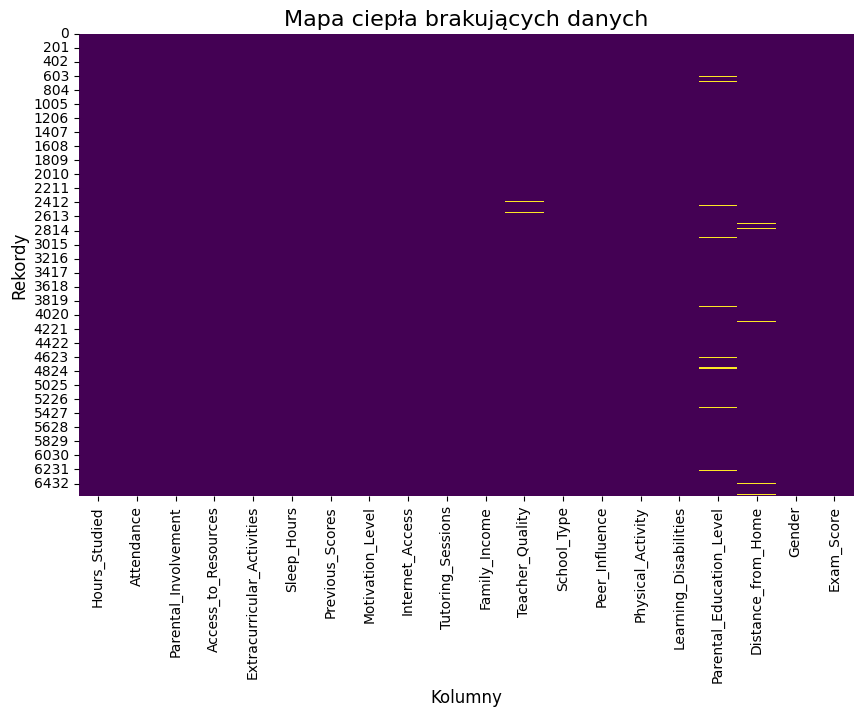

In [107]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa ciepła brakujących danych', fontsize=16)
plt.xlabel('Kolumny', fontsize=12)
plt.ylabel('Rekordy', fontsize=12)

plt.show()

In [108]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

df['Distance_from_Home'] = df['Distance_from_Home'].map({'Near': 0, 'Moderate': 1, 'Far': 2})
median_distance = df['Distance_from_Home'].median()
df['Distance_from_Home'].fillna(median_distance, inplace=True)

df['Access_to_Resources'] = df['Access_to_Resources'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Parental_Involvement'] = df['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Motivation_Level'] = df['Motivation_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

df['Teacher_Quality'] = df['Teacher_Quality'].map({'Low': 0, 'Medium': 1, 'High': 2})
median_distance = df['Teacher_Quality'].median()
df['Teacher_Quality'].fillna(median_distance, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_16180\772998231.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_from_Home'].fillna(median_distance, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16180\772998231.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [109]:
df = pd.get_dummies(df, columns=['Learning_Disabilities','Internet_Access', 'School_Type', 'Extracurricular_Activities'], drop_first=True)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes
0,23,84,0,2,7,73,0,0,Low,1.0,Positive,3,High School,0.0,0,67,False,True,True,False
1,19,64,0,1,8,59,0,2,Medium,1.0,Negative,4,College,1.0,1,61,False,True,True,False
2,24,98,1,1,7,91,1,2,Medium,1.0,Neutral,4,Postgraduate,0.0,0,74,False,True,True,True
3,29,89,0,1,8,98,1,1,Medium,1.0,Negative,4,High School,1.0,0,71,False,True,True,True
4,19,92,1,1,6,65,1,3,Medium,2.0,Neutral,4,College,0.0,1,70,False,True,True,True


In [110]:
df['Family_Income'] = df['Family_Income'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Peer_Influence'] = df['Peer_Influence'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

In [111]:
df['Parental_Education_Level'] = df['Parental_Education_Level'].map({'High School': 0, 'College': 1, 'Postgraduate': 2})
median_distance = df['Parental_Education_Level'].median()
df['Parental_Education_Level'].fillna(median_distance, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_16180\2992307529.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Parental_Education_Level'].fillna(median_distance, inplace=True)


In [112]:
df.head()
print(df.isnull().sum())

Hours_Studied                     0
Attendance                        0
Parental_Involvement              0
Access_to_Resources               0
Sleep_Hours                       0
Previous_Scores                   0
Motivation_Level                  0
Tutoring_Sessions                 0
Family_Income                     0
Teacher_Quality                   0
Peer_Influence                    0
Physical_Activity                 0
Parental_Education_Level          0
Distance_from_Home                0
Gender                            0
Exam_Score                        0
Learning_Disabilities_Yes         0
Internet_Access_Yes               0
School_Type_Public                0
Extracurricular_Activities_Yes    0
dtype: int64


In [113]:
df.drop(['Physical_Activity', 'Sleep_Hours', 'Gender', 'School_Type_Public'], axis=1, inplace=True)

In [114]:
# Define a function to transform 'Exam_Score' into intervals with specified labels
def transform_exam_score(score):
    if score <= 51:
        return 2
    elif 51 < score <= 61:
        return 3
    elif 61 < score <= 71:
        return 3.5
    elif 71 < score <= 81:
        return 4
    elif 81 < score <= 91:
        return 4.5
    else:
        return 5

# Apply the transformation
df['Exam_Score_Category'] = df['Exam_Score'].apply(transform_exam_score)

# Check the transformed column
df.head()

df.drop(['Exam_Score'])


KeyError: "['Exam_Score'] not found in axis"

In [ ]:
y = df['Exam_Score_Category']
X = df.drop(['Exam_Score_Category'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((4624, 16), (1983, 16), (4624,), (1983,))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# # Preprocess the data again for consistency
# X_train_preprocessed = preprocessor.fit_transform(X_train)
# X_test_preprocessed = preprocessor.transform(X_test)

# # Initialize Random Forest model
random_forest_model = RandomForestRegressor(random_state=42, n_estimators=100)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Display the results
random_forest_results = {
    'Model': 'Random Forest',
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf
}
random_forest_results

{'Model': 'Random Forest',
 'MAE': 1.0085728693897919e-05,
 'RMSE': 0.00031758036296184475,
 'R2': 0.9999977707579198}

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

# Train the Gradient Boosting model
gradient_boosting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gradient_boosting_model.predict(X_test)

# Evaluate the Gradient Boosting model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

# Display the results
gradient_boosting_results = {
    'Model': 'Gradient Boosting',
    'MAE': mae_gb,
    'RMSE': rmse_gb,
    'R2': r2_gb
}
gradient_boosting_results


{'Model': 'Gradient Boosting',
 'MAE': 2.7991255844968145e-06,
 'RMSE': 5.649707574404499e-06,
 'R2': 0.9999999992944921}

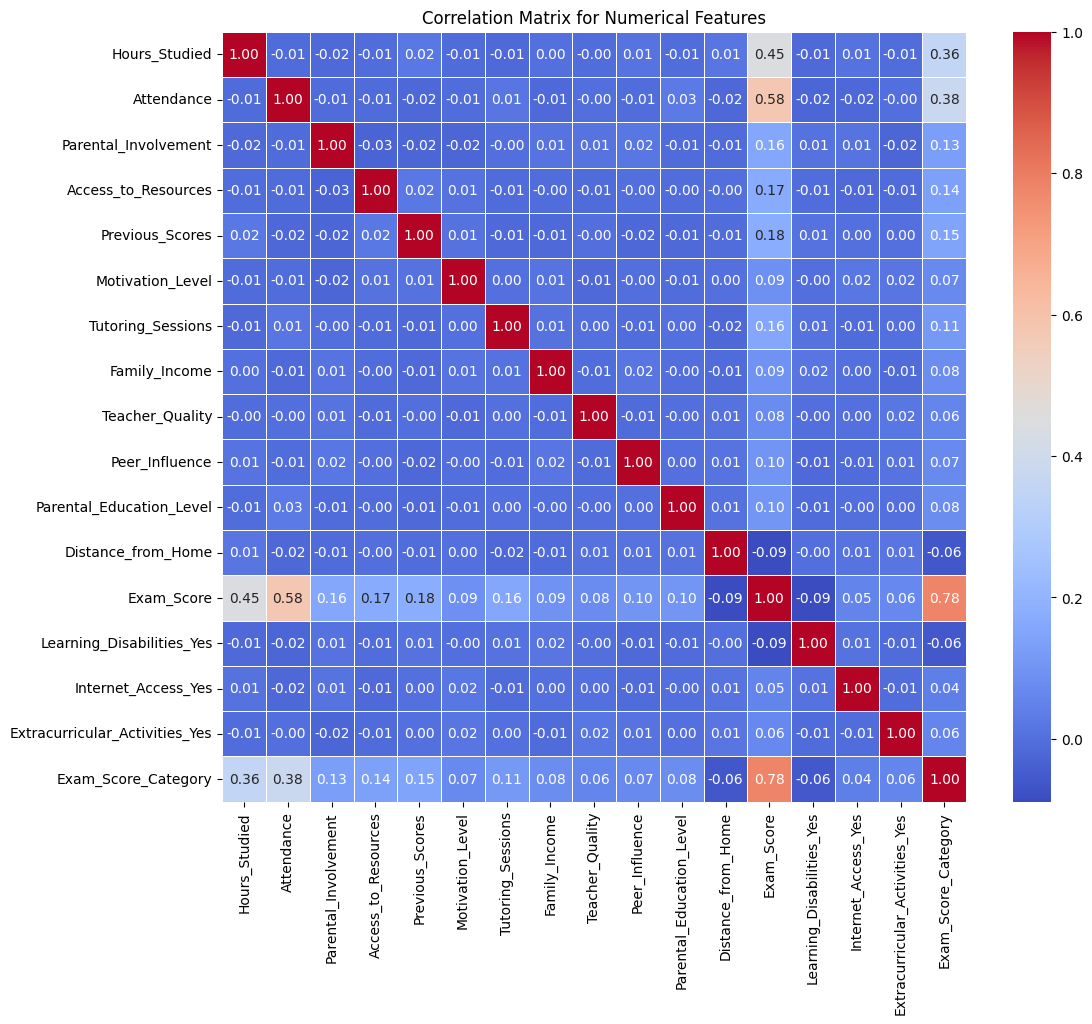

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Parental_Education_Level,Distance_from_Home,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,Extracurricular_Activities_Yes,Exam_Score_Category
0,23,84,0,2,73,0,0,0,1.0,2,0.0,0.0,67,False,True,False,3.5
1,19,64,0,1,59,0,2,1,1.0,0,1.0,1.0,61,False,True,False,3.0
2,24,98,1,1,91,1,2,1,1.0,1,2.0,0.0,74,False,True,True,4.0
3,29,89,0,1,98,1,1,1,1.0,0,0.0,1.0,71,False,True,True,3.5
4,19,92,1,1,65,1,3,1,2.0,1,1.0,0.0,70,False,True,True,3.5


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

df.head()
